In [76]:
import pandas as pd

df = pd.read_csv("tarea.csv", encoding="latin-1",header=1)
df['Value'] = pd.to_numeric(df['Value'],errors='coerce')


In [77]:
#series_and_value = df[['Series','Value']]
filtered_mortality= df[(df['Series']=='Infant mortality for both sexes (per 1,000 live births)') & (df['Year']==2020)]


In [78]:
filtered_life= df[(df['Series']=='Life expectancy at birth for both sexes (years)') & (df['Year']==2020)]


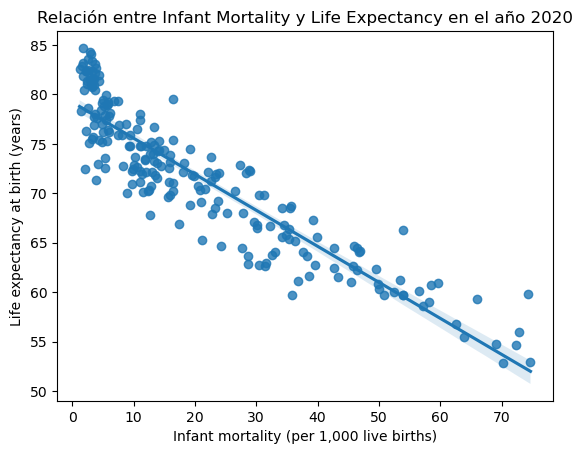

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(x=filtered_mortality['Value'], y=filtered_life['Value'])
plt.xlabel('Infant mortality (per 1,000 live births)')
plt.ylabel('Life expectancy at birth (years)')
plt.title('Relación entre Infant Mortality y Life Expectancy en el año 2020')
plt.show()

El gráfico de regresión lineal muestra una relación inversa (negativa) entre la mortalidad infantil y la esperanza de vida. Es decir, a mayor mortalidad infantil se observa una menor esperanza de vida, mientras que a menor mortalidad infantil corresponde una mayor esperanza de vida.
La línea de regresión confirma la existencia de una correlación negativa entre ambas variables. Asimismo, se identifican algunos valores atípicos (outliers) que se alejan de la línea de regresión, así como una dispersión de los datos alrededor de dicha línea, lo cual refleja variabilidad entre países o regiones.

In [86]:
filtered_2020 = df[df['Year']==2020]

df_corr = filtered_2020.pivot_table(
    index='Region/Country/Area',
    columns='Series',
    values='Value'
)
corr_matrix = df_corr.corr()
corr_matrix


Series,"Infant mortality for both sexes (per 1,000 live births)",Life expectancy at birth for both sexes (years),Life expectancy at birth for females (years),Life expectancy at birth for males (years),"Maternal mortality ratio (deaths per 100,000 population)",Population annual rate of increase (percent),Total fertility rate (children per women)
Series,,,,,,,
"Infant mortality for both sexes (per 1,000 live births)",1.000000,-0.914815,-0.934136,-0.880823,0.871353,0.681320,0.854797
Life expectancy at birth for both sexes (years),-0.914815,1.000000,0.992530,0.991792,-0.823502,-0.639731,-0.844052
Life expectancy at birth for females (years),-0.934136,0.992530,1.000000,0.969268,-0.847502,-0.663784,-0.868663
Life expectancy at birth for males (years),-0.880823,0.991792,0.969268,1.000000,-0.787097,-0.610319,-0.805240
"Maternal mortality ratio (deaths per 100,000 population)",0.871353,-0.823502,-0.847502,-0.787097,1.000000,0.626234,0.808864
Population annual rate of increase (percent),0.681320,-0.639731,-0.663784,-0.610319,0.626234,1.000000,0.762603
Total fertility rate (children per women),0.854797,-0.844052,-0.868663,-0.805240,0.808864,0.762603,1.000000


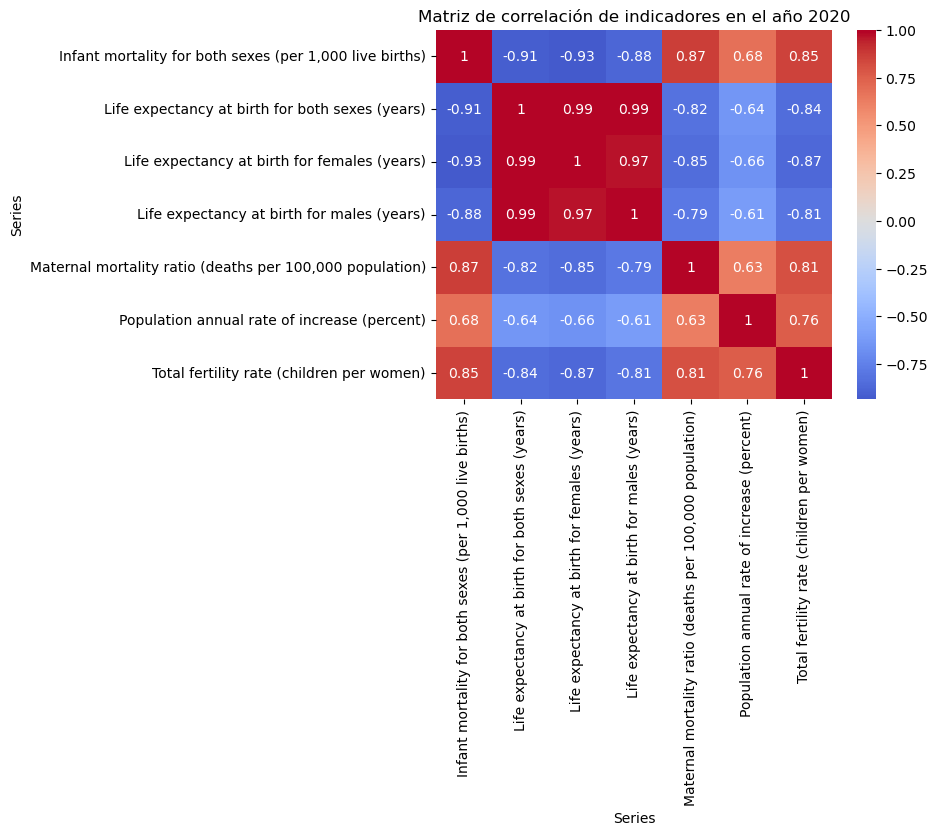

In [108]:
sns.heatmap(corr_matrix,cmap='coolwarm',center=0,annot=True)
plt.title('Matriz de correlación de indicadores en el año 2020')
plt.show()

In [93]:
corr_pairs = (
    corr_matrix
    .unstack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs

Series                                                    Series                                                  
Infant mortality for both sexes (per 1,000 live births)   Infant mortality for both sexes (per 1,000 live births)     1.000000
Life expectancy at birth for both sexes (years)           Life expectancy at birth for both sexes (years)             1.000000
Population annual rate of increase (percent)              Population annual rate of increase (percent)                1.000000
Maternal mortality ratio (deaths per 100,000 population)  Maternal mortality ratio (deaths per 100,000 population)    1.000000
Life expectancy at birth for females (years)              Life expectancy at birth for females (years)                1.000000
Life expectancy at birth for males (years)                Life expectancy at birth for males (years)                  1.000000
Total fertility rate (children per women)                 Total fertility rate (children per women)                   1.000

Para el año 2020, se observa que la mortalidad infantil (Infant mortality for both sexes) presenta una fuerte correlación negativa con la esperanza de vida al nacer (Life expectancy at birth for both sexes). Esto implica que los países o regiones con niveles elevados de mortalidad infantil tienden a registrar una menor esperanza de vida, mientras que aquellos con bajos niveles de mortalidad infantil presentan una mayor esperanza de vida.
Adicionalmente, se identifican otras correlaciones relevantes en la base de datos. Las variables relacionadas con la fecundidad suelen mostrar una correlación positiva con la mortalidad infantil. Por su parte, los indicadores de crecimiento poblacional presentan correlaciones moderadas con los niveles de fecundidad y mortalidad. Asimismo, los indicadores de salud tienden a agruparse, evidenciando patrones consistentes entre sí.